.<center> 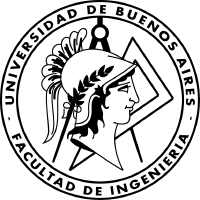



**Universidad de Buenos Aires**

**Facultad de Ingeniería**

**2do Cuatrimestre de 2025**

**Taller de Procesamiento de Señales**

---

**TP2: Regresión Polinómica**

**Alumno:** Lo Coco, Manuel - mlococo@fi.uba.ar - 103938 </center>

---

## (a) Exploración de datos


### (a.1)

Se carga el archivo *car_data.csv* y se descartan las columnas correspondientes al nombre del auto y a su dueño.

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/mvera1412/TA136-TB056-TB057-8625/refs/heads/main/data/car_data.csv"
df=pd.read_csv(url)
data=df.drop(columns=['Car_Name', 'Owner'])
print(data)

     Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type Seller_Type  \
0    2014           3.35           5.59       27000    Petrol      Dealer   
1    2013           4.75           9.54       43000    Diesel      Dealer   
2    2017           7.25           9.85        6900    Petrol      Dealer   
3    2011           2.85           4.15        5200    Petrol      Dealer   
4    2014           4.60           6.87       42450    Diesel      Dealer   
..    ...            ...            ...         ...       ...         ...   
296  2016           9.50          11.60       33988    Diesel      Dealer   
297  2015           4.00           5.90       60000    Petrol      Dealer   
298  2009           3.35          11.00       87934    Petrol      Dealer   
299  2017          11.50          12.50        9000    Diesel      Dealer   
300  2016           5.30           5.90        5464    Petrol      Dealer   

    Transmission    Set  
0         Manual  Train  
1         Manual  Train

### (a.2)

Se definen los conjuntos de entrenamiento, validación y testeo según la columna set y además se descarta esta columna.

In [3]:
data_train=data[data['Set']== 'Train'].drop(columns=['Set'])
data_validation=data[data['Set']== 'Validation'].drop(columns=['Set'])
data_test=data[data['Set']== 'Test'].drop(columns=['Set'])

### (a.3)

Se ven las proporciones de las variables categóricas en forma de probabilidad. Las variables categóricas en este caso son *Fuel_Type*, *Seller_Type* y *Transmission*.

In [4]:
print(data['Fuel_Type'].value_counts(normalize=True),"\n")
print(data['Seller_Type'].value_counts(normalize=True),"\n")
print(data['Transmission'].value_counts(normalize=True),"\n")

Fuel_Type
Petrol    0.794020
Diesel    0.199336
CNG       0.006645
Name: proportion, dtype: float64 

Seller_Type
Dealer        0.647841
Individual    0.352159
Name: proportion, dtype: float64 

Transmission
Manual       0.86711
Automatic    0.13289
Name: proportion, dtype: float64 



## (b) Pre-Procesamiento

Defino las variables que son categóricas, las variables numéricas y la variable a predecir. Además se divide la data en: $X_{\text{train}}$ e $y_{\text{train}}$ ; $X_{\text{validation}}$ e $y_{\text{validation}}$ ; $X_{\text{test}}$ e $y_{\text{test}}$.

In [5]:
import numpy as np

pred_var  = "Selling_Price"
num_vars = ["Present_Price", "Kms_Driven", "Year"]
cat_vars = ["Fuel_Type", "Seller_Type", "Transmission"]

X_train = data_train.drop(columns=pred_var)
y_train = data_train[pred_var]

X_validation = data_validation.drop(columns=pred_var)
y_validation = data_validation[pred_var]

X_test = data_test.drop(columns=pred_var)
y_test = data_test[pred_var]

### (b.1)

Se ultiza *OneHotEncoder* para codificar las variables categóricas de más de dos
clases como one-hot y las categóricas de dos clases como binarias.

In [6]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop="if_binary", sparse_output=False)
cat_encoded = encoder.fit_transform(X_train[cat_vars])
cols_encoded = encoder.get_feature_names_out(cat_vars)
X_train_cat = pd.DataFrame(cat_encoded, columns=cols_encoded)
print(X_train_cat)

     Fuel_Type_CNG  Fuel_Type_Diesel  Fuel_Type_Petrol  \
0              0.0               0.0               1.0   
1              0.0               1.0               0.0   
2              0.0               0.0               1.0   
3              0.0               0.0               1.0   
4              0.0               1.0               0.0   
..             ...               ...               ...   
265            0.0               1.0               0.0   
266            0.0               0.0               1.0   
267            0.0               0.0               1.0   
268            0.0               1.0               0.0   
269            0.0               0.0               1.0   

     Seller_Type_Individual  Transmission_Manual  
0                       0.0                  1.0  
1                       0.0                  1.0  
2                       0.0                  1.0  
3                       0.0                  1.0  
4                       0.0                  1.0

### (b.2)

Se utiliza *PolynomialFeatures* para crear un mapa polinómico de orden 3 sobre
las variables numéricas.

In [7]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3, include_bias=False)
poly.fit_transform(X_train[num_vars])
cols_num = poly.get_feature_names_out(num_vars)
X_train_num = pd.DataFrame(poly.transform(X_train[num_vars]), columns=cols_num)
print(X_train_num)

     Present_Price  Kms_Driven    Year  Present_Price^2  \
0             5.59     27000.0  2014.0          31.2481   
1             9.54     43000.0  2013.0          91.0116   
2             9.85      6900.0  2017.0          97.0225   
3             4.15      5200.0  2011.0          17.2225   
4             9.83      2071.0  2018.0          96.6289   
..             ...         ...     ...              ...   
265          11.60     33988.0  2016.0         134.5600   
266           5.90     60000.0  2015.0          34.8100   
267          11.00     87934.0  2009.0         121.0000   
268          12.50      9000.0  2017.0         156.2500   
269           5.90      5464.0  2016.0          34.8100   

     Present_Price Kms_Driven  Present_Price Year  Kms_Driven^2  \
0                   150930.00            11258.26  7.290000e+08   
1                   410220.00            19204.02  1.849000e+09   
2                    67965.00            19867.45  4.761000e+07   
3                    21

### (b.3)

Se unen los dataframes de las variables categóricas codificadas y el mapa polinómico de orden 3 de las variables numéricas. Para eso se define una transformación con *ColumnTransformer* que al pasarle el dataframe $X_{\text{train}}$ realiza una codificación one-hot o binaria para las categóricas y un mapa polinómico para las numéricas. Luego, se realiza la normalización con *StandardScaler*.

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
import pandas as pd

transformer = ColumnTransformer(
    transformers=[
        ("num", poly, num_vars),
        ("cat", encoder, cat_vars)
    ]
)

scaler = StandardScaler()
X_train_encoded = transformer.fit_transform(X_train)
X_train_scaled_encoded = scaler.fit_transform(X_train_encoded)

num_features = poly.get_feature_names_out(num_vars)
cat_features = encoder.get_feature_names_out(cat_vars)
all_features = list(num_features) + list(cat_features)

X_final = pd.DataFrame(X_train_scaled_encoded, columns=all_features)
print(X_final)

     Present_Price  Kms_Driven      Year  Present_Price^2  \
0        -0.238090   -0.250867  0.126871        -0.194087   
1         0.203504    0.144817 -0.215681        -0.087039   
2         0.238161   -0.747944  1.154529        -0.076272   
3        -0.399076   -0.789986 -0.900786        -0.219210   
4         0.235925   -0.867366  1.497081        -0.076977   
..             ...         ...       ...              ...   
265       0.433804   -0.078052  0.811976        -0.009035   
266      -0.203433    0.565231  0.469424        -0.187707   
267       0.366726    1.256045 -1.585891        -0.033324   
268       0.534420   -0.696011  1.154529         0.029816   
269      -0.203433   -0.783457  0.811976        -0.187707   

     Present_Price Kms_Driven  Present_Price Year  Kms_Driven^2  \
0                   -0.299831           -0.238049     -0.145669   
1                    0.075540            0.203375     -0.074294   
2                   -0.419939            0.240232     -0.189093   

## (c) Regresión Lineal

### (c.1)

Se utiliza *Pipeline* para realizar las operaciones que ya vimos antes (*ColumnTransformer* y *StandarScaler*) y se agrega la regresión lineal con *LinearRegression*. Al pipeline se le entrega un dataframe y realiza las operaciones en el orden que fueron asignadas.

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

pipeline = Pipeline(steps=[
    ("preprocessor", transformer),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

### (c.2)


El modelo tiene 25 parámetros que están distribuidos de la siguiente manera:

* 1 parámetro corresponde al bias
* 19 corresponden a la variables numéricas, que se obtienen haciendo:
$$\begin{pmatrix}3\\3\end{pmatrix}+\begin{pmatrix}3\\2\end{pmatrix}+\begin{pmatrix}3\\1\end{pmatrix}=10+6+3=19$$
* 3 parámetros corresponden a la variable categórica de más de dos clases que usa one-hot
* 2 parámetros corresponde a las variables categóricas de dos clases


### (c.3)

Con la herramienta *display* se puede ver el diagrama definido por el pipeline para la realización de las operaciones, además se observa como se realizan operaciones distintas si las variables son numéricas o categóricas.

In [10]:
display(pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  PolynomialFeatures(degree=3,
                                                                     include_bias=False),
                                                  ['Present_Price',
                                                   'Kms_Driven', 'Year']),
                                                 ('cat',
                                                  OneHotEncoder(drop='if_binary',
                                                                sparse_output=False),
                                                  ['Fuel_Type', 'Seller_Type',
                                                   'Transmission'])])),
                ('scaler', StandardScaler()), ('model', LinearRegression())])

### (c.4)

Se realiza el entrenamiento del sistema.

In [11]:
pipeline.fit(X_train, y_train)
y_pred_train = pipeline.predict(X_train)
y_pred_validation = pipeline.predict(X_validation)
y_pred_test = pipeline.predict(X_test)

### (c.5)

Se imprimen los errores cuadrático medios y se observa que el ECM de entrenamiento es el más bajo, lo cual resulta lógico, ya que el modelo se ajusta directamente sobre esos datos.

In [12]:
print("El error cuadrático medio de entrenamiento es:", np.mean((y_pred_train - y_train)**2))
print("El error cuadrático medio de validación es:", np.mean((y_pred_validation - y_validation)**2))
print("El error cuadrático medio de test es:", np.mean((y_pred_test - y_test)**2))

El error cuadrático medio de entrenamiento es: 0.4726923559618634
El error cuadrático medio de validación es: 0.5419991553074764
El error cuadrático medio de test es: 0.5854715757495652


## (d) Regularización


### (d.1)


Para implementar la regresión polinómica regularizada definimos una función *create_pipeline* que aplica un pipeline con la función *Ridge* para la regresión polinómica con el parámetro $\lambda$ que se le pasa a la función.

A su vez, tomamos $n$ valores aleatorios para $\lambda$ entre $10^{-6}<\lambda<10^{-2}$.

In [13]:
from sklearn.linear_model import Ridge
values=np.random.uniform(1e-6, 1e-2, 300)
values=np.sort(values)

def create_pipeline(var):
    return Pipeline(steps=[
        ("preprocessor", transformer),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=var))
    ])



### (d.2)

Creamos $n$ pipelines para cada valor de $\lambda$, lo entrenamos y calculamos el ECM para cada $\lambda$.

In [14]:
ecm_train = []
ecm_validation = []
ecm_test = []

for i in values:
    pipeline_ridge = create_pipeline(i)
    pipeline_ridge.fit(X_train, y_train)

    y_pred_train_ridge = pipeline_ridge.predict(X_train)
    y_pred_validation_ridge = pipeline_ridge.predict(X_validation)
    y_pred_test_ridge = pipeline_ridge.predict(X_test)

    ecm_train.append(np.mean((y_pred_train_ridge-y_train)**2))
    ecm_validation.append(np.mean((y_pred_validation_ridge-y_validation)**2))
    ecm_test.append(np.mean((y_pred_test_ridge-y_test)**2))

### (d.3)

Graficamos los ECM para entrenamiento, testeo y validación para cada valor de $\lambda$.

En el gráfico se puede ver que para valores muy bajos de $\lambda$ aparece overfitting, ya que el error de entrenamiento es mínimo mientras que los errores de validación y test permanecen altos. En el otro extremo, con $\lambda$ grandes, surge underfitting, dado que el modelo se vuelve demasiado simple y los errores aumentan en todos los conjuntos. Entre ambos extremos se encuentra un valor intermedio de $\lambda$ que representa el mejor equilibrio.

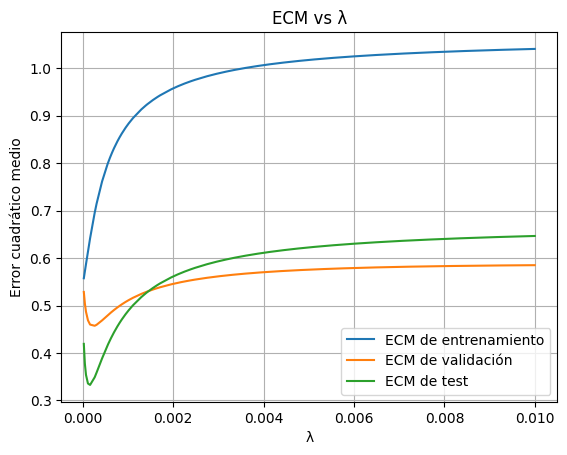

In [15]:
import matplotlib.pyplot as plt

plt.plot(values, ecm_train, label="ECM de entrenamiento")
plt.plot(values, ecm_validation, label="ECM de validación")
plt.plot(values, ecm_test, label="ECM de test")
plt.xlabel("λ")
plt.ylabel("Error cuadrático medio")
plt.title("ECM vs λ")
plt.legend()
plt.grid()
plt.show()

### (d.4)

Para obtener el valor de $\lambda$ que minimiza el ECM de validación, busco el valor mínimo de la curva de validación y luego busco en que valor de $\lambda$ se cumple.

In [16]:
index_min_ecm=np.argmin(ecm_validation)
lambda_opt = values[index_min_ecm]
print("El valor de lambda que minimiza el ECM de validación es:", lambda_opt)

El valor de lambda que minimiza el ECM de validación es: 0.0002648032668121943


### (d.5)

Busco cuánto vale el ECM de testeo para el $\lambda$ óptimo obtenido en el punto anterior.

In [17]:
print("El ECM de testeo para el lambda obtenido es:", ecm_test[index_min_ecm])

El ECM de testeo para el lambda obtenido es: 0.34834070161931746


## Conclusiones

Para finalizar este trabajo se puede concluir que es importante cuando se trabaja con una gran cantidad de datos poder dividirlos en conjuntos de entrenamiento, testeo y validación. Esto ayuda a evaluar correctamente el desempeño del modelo, ya que permite medir qué tan bien aprende de los datos conocidos (entrenamiento) y qué tan capaz es de generalizar a datos nuevos (validación y testeo). Además, facilita detectar problemas como el overfitting o el underfitting.

##